In [1]:
### 1(b)
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

file = "Problem_Set3_2026.xlsx"

# Load total portfolio returns in percent units.
data = pd.read_excel(file, sheet_name="25_Size_BEME_Portfolios", header=None)
names = [f"Size{s}_BM{b}" for s in range(1, 6) for b in range(1, 6)]

ret = data.iloc[3:, 1:26].astype(float)
ret.columns = names
ret.index = pd.PeriodIndex(
    data.iloc[3:, 0].astype(int).astype(str), freq="M"
)
ret = ret.mask(ret <= -99)

market = pd.read_excel(file, sheet_name="Market_proxy", header=None)
market = market.iloc[6:, :3].astype(float)
market.columns = ["date", "MktRF", "RF"]
market.index = pd.PeriodIndex(
    market["date"].astype(int).astype(str), freq="M"
)
market = market[["MktRF", "RF"]]
market = market.mask(market <= -99)

assert ret.shape[1] == 25
assert ret.index.is_unique and market.index.is_unique
assert ret.index.equals(market.index)
assert ret.index.equals(pd.period_range("1926-07", "2026-06", freq="M"))
assert ret.notna().all().all() and market.notna().all().all()

# Match the main sample used in Part I.
start = "1969-07"
ret = ret.loc[start:]
market = market.loc[ret.index]
exret = ret.sub(market["RF"], axis=0)
rm = market["MktRF"]

# First pass: one fixed beta per portfolio.
betas = pd.Series(index=names, dtype=float, name="beta")
X_market = sm.add_constant(rm)

for name in names:
    fit = sm.OLS(exret[name], X_market).fit()
    betas[name] = fit.params["MktRF"]

# Second pass: monthly cross-sectional regressions.
X = sm.add_constant(betas)
gammas = pd.DataFrame(
    index=exret.index, columns=["gamma_0", "gamma_M"], dtype=float
)
r2 = pd.Series(index=exret.index, dtype=float)

for date in exret.index:
    fit = sm.OLS(exret.loc[date], X).fit()
    gammas.loc[date] = fit.params.to_numpy()
    r2.loc[date] = fit.rsquared

# Third pass: time-series averages and FMB standard errors.
T = len(gammas)
fmb = pd.DataFrame({
    "Estimate": gammas.mean(),
    "FMB SE": gammas.std(ddof=1) / np.sqrt(T)
})
fmb["t-stat"] = fmb["Estimate"] / fmb["FMB SE"]
fmb["p-value"] = 2 * stats.t.sf(fmb["t-stat"].abs(), T - 1)

# CAPM slope restriction, accounting for the estimated market premium.
gap = gammas["gamma_M"] - rm
gap_se = gap.std(ddof=1) / np.sqrt(T)
gap_t = gap.mean() / gap_se
gap_p = 2 * stats.t.sf(abs(gap_t), T - 1)

print(f"Sample: {exret.index[0]} to {exret.index[-1]} | T = {T} | N = 25")
print("Estimates and standard errors: percentage points per month.")
print("\nFama–MacBeth estimates (t-statistics test zero):")
print(fmb.round(4).to_string())

print(f"\nMean market excess return: {rm.mean():.4f}")
print(f"Average monthly cross-sectional R-squared: {r2.mean():.4f}")

print("\nSlope restriction: E(gamma_M,t - MktRF_t) = 0")
print(f"Mean difference = {gap.mean():.4f}, SE = {gap_se:.4f}")
print(f"t-stat = {gap_t:.4f}, p-value = {gap_p:.4f}")

Sample: 1969-07 to 2026-06 | T = 684 | N = 25
Estimates and standard errors: percentage points per month.

Fama–MacBeth estimates (t-statistics test zero):
         Estimate  FMB SE  t-stat  p-value
gamma_0    1.3554  0.3998   3.390   0.0007
gamma_M   -0.5758  0.4290  -1.342   0.1800

Mean market excess return: 0.6116
Average monthly cross-sectional R-squared: 0.2425

Slope restriction: E(gamma_M,t - MktRF_t) = 0
Mean difference = -1.1873, SE = 0.3916
t-stat = -3.0316, p-value = 0.0025


In [2]:
### 1(c)
avg_ret = exret.mean()
cs = sm.OLS(avg_ret, sm.add_constant(betas)).fit()

comparison = pd.DataFrame({
    "FMB estimate": fmb["Estimate"].to_numpy(),
    "FMB SE": fmb["FMB SE"].to_numpy(),
    "FMB t-stat": fmb["t-stat"].to_numpy(),
    "OLS estimate": cs.params.to_numpy(),
    "OLS SE": cs.bse.to_numpy(),
    "OLS t-stat": cs.tvalues.to_numpy()
}, index=["gamma_0", "gamma_M"])

print(comparison.round(4).to_string())
print(f"\nCross-sectional R-squared: {cs.rsquared:.4f}")
print(f"N = {int(cs.nobs)}")
print(f"Point estimates match: {np.allclose(cs.params, fmb['Estimate'])}")

         FMB estimate  FMB SE  FMB t-stat  OLS estimate  OLS SE  OLS t-stat
gamma_0        1.3554  0.3998       3.390        1.3554  0.2619      5.1759
gamma_M       -0.5758  0.4290      -1.342       -0.5758  0.2411     -2.3884

Cross-sectional R-squared: 0.1987
N = 25
Point estimates match: True


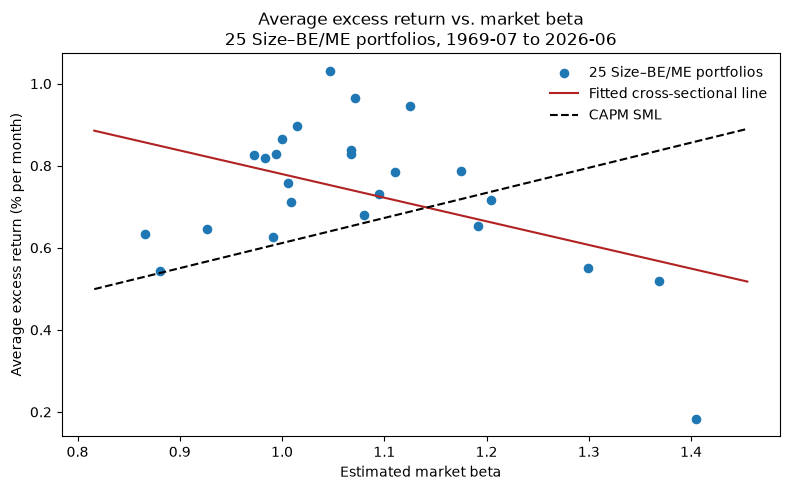

Fitted line: 1.3554 + (-0.5758) × beta
CAPM SML: 0.6116 × beta
Cross-sectional R-squared: 0.1987


In [3]:
### 1(d)
import matplotlib.pyplot as plt

x = np.linspace(betas.min() - 0.05, betas.max() + 0.05, 100)
premium = rm.mean()

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(betas, avg_ret, s=35, label="25 Size–BE/ME portfolios")
ax.plot(
    x, cs.params["const"] + cs.params["beta"] * x,
    color="firebrick", label="Fitted cross-sectional line"
)
ax.plot(
    x, premium * x, "--",
    color="black", label="CAPM SML"
)

ax.set_xlabel("Estimated market beta")
ax.set_ylabel("Average excess return (% per month)")
ax.set_title(
    f"Average excess return vs. market beta\n"
    f"25 Size–BE/ME portfolios, {exret.index[0]} to {exret.index[-1]}"
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"Fitted line: {cs.params['const']:.4f} + ({cs.params['beta']:.4f}) × beta")
print(f"CAPM SML: {premium:.4f} × beta")
print(f"Cross-sectional R-squared: {cs.rsquared:.4f}")

In [4]:
### 1(f)
assert np.array_equal(data.iloc[1:3, 1:26], data.iloc[1:3, 28:53])
assert np.array_equal(data.iloc[1:3, 1:26], data.iloc[1:3, 55:80])

size = data.iloc[3:, 28:53].astype(float)
size.columns = names
size.index = pd.PeriodIndex(
    data.iloc[3:, 27].astype(int).astype(str), freq="M"
)
size = size.mask(size <= 0)

annual = data.iloc[3:, 54:80].dropna(subset=[54]).astype(float)
bm = annual.iloc[:, 1:].copy()
bm.columns = names
bm.index = annual.iloc[:, 0].astype(int)
bm = bm.mask(bm <= 0)

assert size.index.is_unique and bm.index.is_unique
assert size.index.equals(
    pd.period_range(size.index.min(), size.index.max(), freq="M")
)

ln_size = np.log(size).shift(1).reindex(exret.index)
ln_bm = np.log(bm).reindex(exret.index.year - 1)
ln_bm.index = exret.index

assert ln_size.notna().all().all()
assert ln_bm.notna().all().all()

# Monthly regressions using fixed betas and lagged characteristics.
terms = ["gamma_0", "gamma_M", "gamma_size", "gamma_BM"]
gammas_ext = pd.DataFrame(index=exret.index, columns=terms, dtype=float)
r2_ext = pd.Series(index=exret.index, dtype=float)

for date in exret.index:
    X_ext = pd.DataFrame({
        "beta": betas,
        "ln_size": ln_size.loc[date],
        "ln_bm": ln_bm.loc[date]
    })
    fit = sm.OLS(exret.loc[date], sm.add_constant(X_ext)).fit()
    gammas_ext.loc[date] = fit.params.to_numpy()
    r2_ext.loc[date] = fit.rsquared

T_ext = len(gammas_ext)
fmb_ext = pd.DataFrame({
    "Estimate": gammas_ext.mean(),
    "FMB SE": gammas_ext.std(ddof=1) / np.sqrt(T_ext)
})
fmb_ext["t-stat"] = fmb_ext["Estimate"] / fmb_ext["FMB SE"]
fmb_ext["p-value"] = 2 * stats.t.sf(
    fmb_ext["t-stat"].abs(), T_ext - 1
)

gap_ext = gammas_ext["gamma_M"] - rm
gap_ext_se = gap_ext.std(ddof=1) / np.sqrt(T_ext)
gap_ext_t = gap_ext.mean() / gap_ext_se
gap_ext_p = 2 * stats.t.sf(abs(gap_ext_t), T_ext - 1)

print(f"Sample: {exret.index[0]} to {exret.index[-1]} | T = {T_ext} | N = 25")
print("\nExtended Fama–MacBeth estimates (t-statistics test zero):")
print(fmb_ext.round(4).to_string())

print(f"\nMean market excess return: {rm.mean():.4f}")
print(f"Average monthly R-squared, beta only: {r2.mean():.4f}")
print(f"Average monthly R-squared, extended: {r2_ext.mean():.4f}")

print("\nSlope restriction: E(gamma_M,t - MktRF_t) = 0")
print(f"Mean difference = {gap_ext.mean():.4f}, SE = {gap_ext_se:.4f}")
print(f"t-stat = {gap_ext_t:.4f}, p-value = {gap_ext_p:.4f}")

Sample: 1969-07 to 2026-06 | T = 684 | N = 25

Extended Fama–MacBeth estimates (t-statistics test zero):
            Estimate  FMB SE  t-stat  p-value
gamma_0       1.1539  0.3392  3.4017   0.0007
gamma_M      -0.2646  0.3134 -0.8442   0.3989
gamma_size   -0.0194  0.0302 -0.6428   0.5206
gamma_BM      0.1573  0.0747  2.1055   0.0356

Mean market excess return: 0.6116
Average monthly R-squared, beta only: 0.2425
Average monthly R-squared, extended: 0.5288

Slope restriction: E(gamma_M,t - MktRF_t) = 0
Mean difference = -0.8761, SE = 0.2629
t-stat = -3.3320, p-value = 0.0009


### 1(b)

Using fixed full-period betas and 684 monthly cross-sectional regressions, we obtain $\bar{\gamma}_0=1.3554$ (FMB SE = 0.3998, $t=3.390$) and $\bar{\gamma}_M=-0.5758$ (FMB SE = 0.4290, $t=-1.342$), in percent per month. Standard errors use $sd(\hat{\gamma}_{j,t})/\sqrt{T}$.

The significantly positive intercept rejects the zero-intercept restriction. The slope also falls below the average market excess return of 0.6116%; the difference has $t=-3.0316$ and $p=0.0025$. These results reject the Sharpe–Lintner CAPM restrictions and provide evidence against the proxy being the tangency portfolio for these assets. The insignificant slope relative to zero is not, by itself, grounds for rejection.

### 1(c)

The single cross-sectional regression gives the same coefficients as Fama–MacBeth: $\gamma_0=1.3554$ and $\gamma_M=-0.5758$, with $R^2=0.1987$ and $N=25$. Equality follows because the panel is balanced and the regressors are fixed: averaging monthly OLS coefficients is equivalent to regressing average returns on the same betas.

The OLS standard errors, 0.2619 and 0.2411, are smaller than the FMB standard errors, 0.3998 and 0.4290. OLS measures dispersion around the average-return regression, whereas FMB measures variation in monthly coefficient estimates. FMB is preferable for inference on average premia here because it incorporates that time-series variation and accommodates contemporaneous correlation across portfolio returns. It does not eliminate error from estimated betas.

### 1(d)

The plot shows a negative fitted relationship:

$$
\overline{R_i^e}=1.3554-0.5758\hat{\beta}_{iM}.
$$

The CAPM instead predicts a line through the origin with positive slope 0.6116. The portfolios are widely scattered around the fitted line, with $R^2=0.1987$, so market beta explains little of their average-return variation. The plot is inconsistent with the predicted SML, although visual evidence alone is not a formal statistical test.

### 1(f)

With lagged characteristics included, the estimates are $\gamma_0=1.1539$ ($t=3.4017$), $\gamma_M=-0.2646$ ($t=-0.8442$), $\gamma_{size}=-0.0194$ ($t=-0.6428$), and $\gamma_{B/M}=0.1573$ ($t=2.1055$). Book-to-market has a positive premium significant at 5%, while size is insignificant. Average monthly cross-sectional $R^2$ rises from 0.2425 to 0.5288.

The positive book-to-market premium contradicts the CAPM prediction that characteristics have no additional explanatory power after controlling for beta. The intercept remains significantly positive, and the beta premium remains below the market premium ($t=-3.3320$, $p=0.0009$). Thus, adding characteristics does not restore the Sharpe–Lintner CAPM restrictions.

Size is lagged one month and BE/ME uses the previous year's value, held constant within each year. This follows the assignment's information-timing convention and avoids using contemporaneous characteristics, though actual accounting-data availability would require publication dates.

### question 2

In [ ]:

mu = exret.mean()
cov = exret.cov()

raw_weights = np.linalg.solve(cov, mu)
weights_tan = pd.Series(
    raw_weights / raw_weights.sum(),
    index=exret.columns,
    name="Weight"
)


rm_tan = (exret @ weights_tan).rename("MktRF_tan")
ret_tan = rm_tan + market["RF"]


betas_tan = pd.Series(
    index=exret.columns, dtype=float, name="Tangency beta"
)
X_tan = sm.add_constant(rm_tan)

for name in exret.columns:
    fit = sm.OLS(exret[name], X_tan).fit()
    betas_tan[name] = fit.params["MktRF_tan"]

assert np.isclose(weights_tan.sum(), 1)
assert np.allclose(ret @ weights_tan, ret_tan)

print(f"Sample: {exret.index[0]} to {exret.index[-1]} | T = {len(exret)}")
print(pd.concat([weights_tan, betas_tan], axis=1).round(4).to_string())

print(f"\nSum of weights: {weights_tan.sum():.6f}")
print(f"Gross exposure (sum of absolute weights): {weights_tan.abs().sum():.4f}")
print(f"Mean excess return (% per month): {rm_tan.mean():.4f}")
print(f"Monthly volatility (%): {rm_tan.std(ddof=1):.4f}")
print(f"Monthly Sharpe ratio: {rm_tan.mean() / rm_tan.std(ddof=1):.4f}")
print(f"Weighted average beta: {weights_tan @ betas_tan:.6f}")

Sample: 1969-07 to 2026-06 | T = 684
           Weight  Tangency beta
Size1_BM1 -1.9858         0.0725
Size1_BM2  0.6508         0.2841
Size1_BM3 -0.0034         0.2903
Size1_BM4  0.9189         0.3563
Size1_BM5  0.9936         0.4092
Size2_BM1 -0.2076         0.2061
Size2_BM2  0.8054         0.3119
Size2_BM3  0.2286         0.3289
Size2_BM4 -0.0409         0.3435
Size2_BM5 -0.4743         0.3749
Size3_BM1 -0.6186         0.2183
Size3_BM2  0.0531         0.3109
Size3_BM3 -0.6615         0.2819
Size3_BM4 -0.2411         0.3253
Size3_BM5  0.2578         0.3834
Size4_BM1  1.1460         0.2595
Size4_BM2 -0.6837         0.2694
Size4_BM3 -0.0040         0.3006
Size4_BM4  0.4626         0.3274
Size4_BM5 -0.1819         0.3330
Size5_BM1  0.7176         0.2484
Size5_BM2  0.0421         0.2559
Size5_BM3  0.5150         0.2519
Size5_BM4 -1.0900         0.2154
Size5_BM5  0.4014         0.3288

Sum of weights: 1.000000
Gross exposure (sum of absolute weights): 13.3859
Mean excess return (% per mon

In [ ]:
cs_tan = sm.OLS(
    avg_ret, sm.add_constant(betas_tan.rename("beta"))
).fit()

results_tan = pd.DataFrame({
    "Estimate": cs_tan.params.to_numpy(),
    "OLS SE": cs_tan.bse.to_numpy(),
    "t-stat": cs_tan.tvalues.to_numpy()
}, index=["gamma_0", "gamma_M"])

print(results_tan.to_string(float_format=lambda v: f"{v:.6g}"))
print(f"\nCross-sectional R-squared: {cs_tan.rsquared:.6f}")
print(f"N = {int(cs_tan.nobs)}")
print(f"Mean tangency excess return: {rm_tan.mean():.4f}% per month")
print(f"Maximum absolute regression residual: {cs_tan.resid.abs().max():.3e}")

           Estimate      OLS SE     t-stat
gamma_0 4.83988e-15 4.34718e-15    1.11334
gamma_M     2.52036 1.45191e-14 1.7359e+14

Cross-sectional R-squared: 1.000000
N = 25
Mean tangency excess return: 2.5204% per month
Maximum absolute regression residual: 9.659e-15


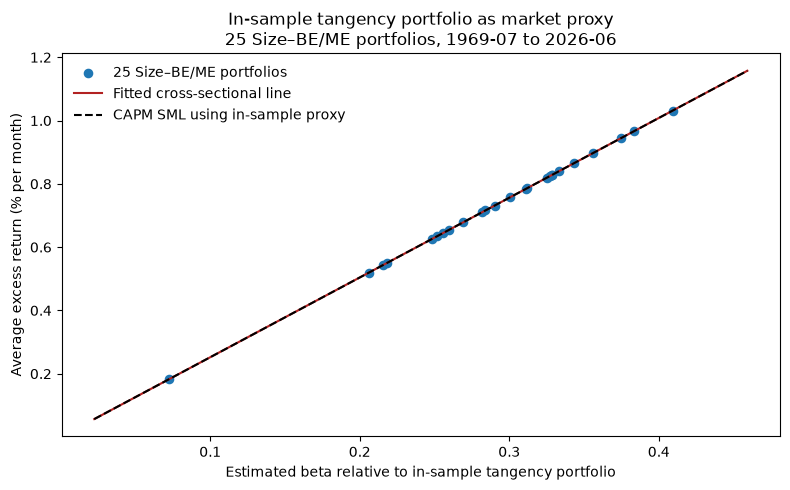

Fitted line: 0.0000 + (2.5204) × beta
CAPM SML: 2.5204 × beta


In [ ]:
x_tan = np.linspace(betas_tan.min() - 0.05, betas_tan.max() + 0.05, 100)
premium_tan = rm_tan.mean()

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(betas_tan, avg_ret, s=35, label="25 Size–BE/ME portfolios")
ax.plot(
    x_tan, cs_tan.params["const"] + cs_tan.params["beta"] * x_tan,
    color="firebrick", label="Fitted cross-sectional line"
)
ax.plot(
    x_tan, premium_tan * x_tan, "--",
    color="black", label="CAPM SML using in-sample proxy"
)

ax.set_xlabel("Estimated beta relative to in-sample tangency portfolio")
ax.set_ylabel("Average excess return (% per month)")
ax.set_title(
    f"In-sample tangency portfolio as market proxy\n"
    f"25 Size–BE/ME portfolios, {exret.index[0]} to {exret.index[-1]}"
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"Fitted line: {cs_tan.params['const']:.4f} + ({cs_tan.params['beta']:.4f}) × beta")
print(f"CAPM SML: {premium_tan:.4f} × beta")

### 2(a)

Using the 684 monthly observations from July 1969 to June 2026, we calculate the sample mean vector $\hat{\mu}$ and covariance matrix $\hat{\Sigma}$ of the 25 portfolios' excess returns. The tangency weights are

$$
w_T =
\frac{\hat{\Sigma}^{-1}\hat{\mu}}
{\mathbf{1}'\hat{\Sigma}^{-1}\hat{\mu}}.
$$

The weights sum to one, with short selling allowed.

| Portfolio | Weight | Portfolio | Weight |
|---|---:|---|---:|
| Size1_BM1 | -1.9858 | Size3_BM4 | -0.2411 |
| Size1_BM2 | 0.6508 | Size3_BM5 | 0.2578 |
| Size1_BM3 | -0.0034 | Size4_BM1 | 1.1460 |
| Size1_BM4 | 0.9189 | Size4_BM2 | -0.6837 |
| Size1_BM5 | 0.9936 | Size4_BM3 | -0.0040 |
| Size2_BM1 | -0.2076 | Size4_BM4 | 0.4626 |
| Size2_BM2 | 0.8054 | Size4_BM5 | -0.1819 |
| Size2_BM3 | 0.2286 | Size5_BM1 | 0.7176 |
| Size2_BM4 | -0.0409 | Size5_BM2 | 0.0421 |
| Size2_BM5 | -0.4743 | Size5_BM3 | 0.5150 |
| Size3_BM1 | -0.6186 | Size5_BM4 | -1.0900 |
| Size3_BM2 | 0.0531 | Size5_BM5 | 0.4014 |
| Size3_BM3 | -0.6615 |  |  |

Weights are reported as fractions of portfolio value. Size and BE/ME groups increase from 1 to 5. Gross exposure,

$$
\sum_i |w_i|,
$$

is 13.3859, indicating substantial offsetting long and short positions.

### 2(b) Returns, betas, and cross-sectional results

We construct the tangency portfolio's monthly excess return using the same fixed weights throughout:

$$
R^e_{T,t}
=
\sum_{i=1}^{25} w_{T,i}R^e_{i,t}.
$$

Its average excess return is **2.5204% per month**, monthly volatility is **6.0461%**, and the monthly Sharpe ratio is **0.4169**.

We estimate each portfolio's beta by regressing its excess returns on $R^e_{T,t}$, including an intercept. Regressing average excess returns on these new betas gives

$$
\overline{R_i^e}
\approx
0 + 2.5204\,\hat{\beta}_{i,T},
\qquad
R^2 = 1,\quad N=25.
$$

The estimated intercept is effectively zero, while the slope equals the tangency portfolio's average excess return. All 25 portfolios lie essentially on the theoretical SML, so the fitted and theoretical lines overlap. The OLS standard errors are effectively zero; the resulting t-statistics are not economically meaningful because the fit is mechanically exact.

#### 2c
This perfect fit does not independently support the CAPM. The tangency portfolio is constructed to be mean–variance efficient using the same assets and observations used in the regression. Its weights satisfy $$(w_T\propto\hat\Sigma^{-1}\hat\mu)$$, which implies
$$
\hat\mu_i=\hat\beta_{i,T}\hat\mu_T.
$$
Thus, the zero intercept, matching slope, and perfect fit follow from portfolio mathematics.

This illustrates Roll’s critique: CAPM tests depend on whether the chosen market proxy is mean–variance efficient. The true market portfolio includes all wealth and is not directly observable. Rejecting the CAPM with a particular proxy could therefore reflect a poor proxy, while obtaining a perfect fit with a deliberately constructed tangency portfolio does not establish that the true market portfolio is efficient.

### question 3

In [ ]:
year = exret.index.year
month = exret.index.month

mask1 = ((year % 2 == 0) & (month % 2 == 1)) | (
    (year % 2 == 1) & (month % 2 == 0)
)
mask2 = ((year % 2 == 0) & (month % 2 == 0)) | (
    (year % 2 == 1) & (month % 2 == 1)
)

assert exret.index.is_unique
assert exret.shape[1] == 25 and exret.notna().all().all()
assert not (mask1 & mask2).any()
assert (mask1 | mask2).all()

sample1 = exret.loc[mask1]
sample2 = exret.loc[mask2]

print(f"Sample 1: {len(sample1)} months | Sample 2: {len(sample2)} months")
print(f"Total: {len(exret)} months; no overlap and complete coverage.")
print("First six Sample 1 dates:", ", ".join(sample1.index[:6].astype(str)))
print("First six Sample 2 dates:", ", ".join(sample2.index[:6].astype(str)))

Sample 1: 342 months | Sample 2: 342 months
Total: 684 months; no overlap and complete coverage.
First six Sample 1 dates: 1969-08, 1969-10, 1969-12, 1970-01, 1970-03, 1970-05
First six Sample 2 dates: 1969-07, 1969-09, 1969-11, 1970-02, 1970-04, 1970-06


In [ ]:
mu1 = sample1.mean()
cov1 = sample1.cov()
raw1 = np.linalg.solve(cov1, mu1)

mu2 = sample2.mean()
cov2 = sample2.cov()
raw2 = np.linalg.solve(cov2, mu2)

assert not np.isclose(raw1.sum(), 0)
assert not np.isclose(raw2.sum(), 0)

weights1 = pd.Series(raw1 / raw1.sum(), index=exret.columns)
weights2 = pd.Series(raw2 / raw2.sum(), index=exret.columns)

assert np.isfinite(weights1).all() and np.isfinite(weights2).all()
assert np.isclose(weights1.sum(), 1)
assert np.isclose(weights2.sum(), 1)

weight_checks = pd.DataFrame({
    "Estimated from": ["Sample 1", "Sample 2"],
    "Applied to": ["Sample 2", "Sample 1"],
    "Weight sum": [weights1.sum(), weights2.sum()],
    "Gross exposure": [weights1.abs().sum(), weights2.abs().sum()],
    "Min weight": [weights1.min(), weights2.min()],
    "Max weight": [weights1.max(), weights2.max()]
})
print(weight_checks.round(4).to_string(index=False))

Estimated from Applied to  Weight sum  Gross exposure  Min weight  Max weight
      Sample 1   Sample 2         1.0         15.4800     -1.6671      1.4736
      Sample 2   Sample 1         1.0         17.2082     -2.4853      1.3680


In [ ]:
oos_sample2 = sample2 @ weights1
oos_sample1 = sample1 @ weights2

# Each return's date must be absent from its weight-estimation sample.
assert oos_sample2.index.intersection(sample1.index).empty
assert oos_sample1.index.intersection(sample2.index).empty

rm_oos = pd.concat([oos_sample1, oos_sample2]).sort_index()
rm_oos.name = "MktRF_OOS"

assert rm_oos.index.is_unique
assert rm_oos.index.equals(exret.index.sort_values())
assert np.isfinite(rm_oos).all()

print(f"OOS series: {rm_oos.index[0]} to {rm_oos.index[-1]} | T = {len(rm_oos)}")
print("Checks passed: every month uses weights estimated from the other sample.")
print(f"Mean excess return (% per month): {rm_oos.mean():.4f}")
print(f"Monthly volatility (%): {rm_oos.std(ddof=1):.4f}")
print(f"Monthly Sharpe ratio: {rm_oos.mean() / rm_oos.std(ddof=1):.4f}")
print("\nFirst six OOS excess returns:")
print(rm_oos.head(6).round(4).to_string())

OOS series: 1969-07 to 2026-06 | T = 684
Checks passed: every month uses weights estimated from the other sample.
Mean excess return (% per month): 1.9754
Monthly volatility (%): 7.0300
Monthly Sharpe ratio: 0.2810

First six OOS excess returns:
0
1969-07    1.5900
1969-08    5.3835
1969-09   -2.4048
1969-10   -2.7595
1969-11    3.0593
1969-12    4.9511
Freq: M


In [ ]:
assert rm_oos.index.equals(exret.index)

betas_oos = pd.Series(index=exret.columns, dtype=float, name="beta")
X_oos = sm.add_constant(rm_oos)

for name in exret.columns:
    fit = sm.OLS(exret[name], X_oos).fit()
    betas_oos[name] = fit.params["MktRF_OOS"]

cs_oos = sm.OLS(avg_ret, sm.add_constant(betas_oos)).fit()

results_oos = pd.DataFrame({
    "Estimate": cs_oos.params.to_numpy(),
    "OLS SE": cs_oos.bse.to_numpy(),
    "t-stat": cs_oos.tvalues.to_numpy()
}, index=["gamma_0", "gamma_M"])

print(results_oos.round(4).to_string())
print(f"\nCross-sectional R-squared: {cs_oos.rsquared:.4f}")
print(f"N = {int(cs_oos.nobs)}")
print(f"Mean OOS market excess return: {rm_oos.mean():.4f}% per month")

         Estimate  OLS SE   t-stat
gamma_0    0.0684  0.0228   2.9930
gamma_M    3.2851  0.1091  30.1058

Cross-sectional R-squared: 0.9753
N = 25
Mean OOS market excess return: 1.9754% per month


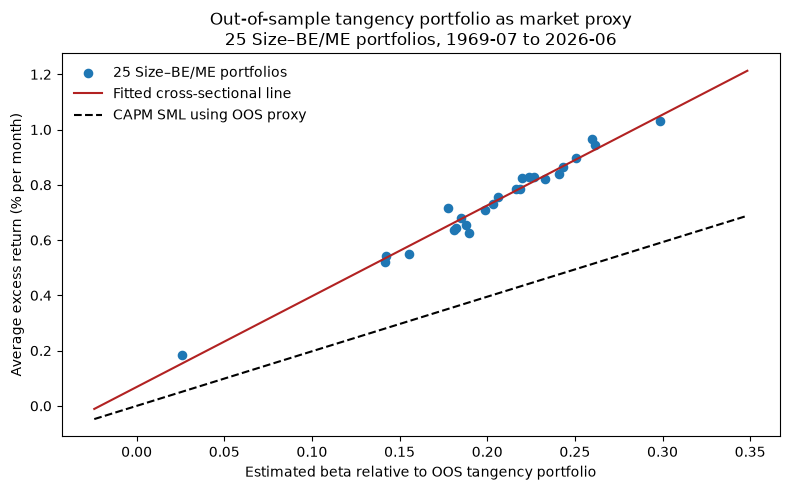

Fitted line: 0.0684 + (3.2851) × beta
CAPM SML: 1.9754 × beta


In [ ]:
x_oos = np.linspace(betas_oos.min() - 0.05, betas_oos.max() + 0.05, 100)
premium_oos = rm_oos.mean()

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(betas_oos, avg_ret, s=35, label="25 Size–BE/ME portfolios")
ax.plot(
    x_oos, cs_oos.params["const"] + cs_oos.params["beta"] * x_oos,
    color="firebrick", label="Fitted cross-sectional line"
)
ax.plot(
    x_oos, premium_oos * x_oos, "--",
    color="black", label="CAPM SML using OOS proxy"
)

ax.set_xlabel("Estimated beta relative to OOS tangency portfolio")
ax.set_ylabel("Average excess return (% per month)")
ax.set_title(
    f"Out-of-sample tangency portfolio as market proxy\n"
    f"25 Size–BE/ME portfolios, {exret.index[0]} to {exret.index[-1]}"
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"Fitted line: {cs_oos.params['const']:.4f} + ({cs_oos.params['beta']:.4f}) × beta")
print(f"CAPM SML: {premium_oos:.4f} × beta")

### 3(a)

Sample 1 contains odd-numbered months in even years and even-numbered months in odd years, giving 342 observations. Using only these observations, we estimate the mean vector and covariance matrix of excess returns and calculate

$$
w_1=\frac{\hat{\Sigma}_1^{-1}\hat{\mu}_1}
{\mathbf{1}'\hat{\Sigma}_1^{-1}\hat{\mu}_1}.
$$

The weights sum to 1, with gross exposure $\sum_i|w_{1,i}|=15.4800$ and individual weights ranging from -1.6671 to 1.4736. We hold these weights fixed and apply them to the 342 months in Sample 2. These returns are out of sample because none of the evaluation observations were used to estimate the weights.

### 3(b)

Sample 2 contains even-numbered months in even years and odd-numbered months in odd years, also giving 342 observations. We estimate a separate tangency portfolio using only Sample 2's mean vector and covariance matrix, with the same normalization.

These weights sum to 1, have gross exposure of 17.2082, and range from -2.4853 to 1.3680. We then apply them, unchanged, to Sample 1 returns. This reverses the estimation and evaluation samples, ensuring that neither half is evaluated using weights estimated from itself. The checks confirm that the samples do not overlap and together cover all 684 months.

### 3(c)

We combine Sample 1 returns generated with $w_2$ and Sample 2 returns generated with $w_1$, then sort them chronologically. The resulting OOS tangency series covers July 1969–June 2026 and has a mean excess return of **1.9754% per month**, monthly volatility of **7.0300%**, and monthly Sharpe ratio of **0.2810**.

We use this combined excess-return series as the market proxy and estimate each portfolio's beta through a full-period time-series regression with an intercept. The cross-sectional regression of average excess returns on these betas is

$$
\overline{R_i^e}
=0.0684+3.2851\hat{\beta}_{i,OOS}+\hat{\eta}_i.
$$

| Coefficient | Estimate | OLS standard error | t-statistic |
|---|---:|---:|---:|
| $\gamma_0$ | 0.0684 | 0.0228 | 2.9930 |
| $\gamma_M$ | 3.2851 | 0.1091 | 30.1058 |

Returns are measured in percent per month. The regression has $R^2=0.9753$ and $N=25$.

The plot shows a strong positive relationship: the portfolios cluster closely around the fitted line, which explains 97.53% of the cross-sectional variation in average excess returns. However, the fitted line lies above the theoretical SML, whose intercept is zero and slope is 1.9754. Thus, a close fit to the estimated line does not establish that the CAPM restrictions hold. The reported slope t-statistic tests equality to zero, not equality to 1.9754.

Each month's return is excluded from the sample used to estimate its portfolio weights. Because the two samples are interleaved in time, this is a held-out-sample exercise rather than a strictly forward-looking trading backtest.

## Question 4

### 1. Comparing the results

| Statistic | Q2: In-sample tangency | Q3: Out-of-sample tangency |
|---|---:|---:|
| $\gamma_0$ (SE, t) | $4.84\times10^{-15}$ $(4.35\times10^{-15},\ t=1.11)$ | $0.0684$ $(0.0228,\ t=2.99)$ |
| $\gamma_M$ (SE, t) | $2.5204$ $(1.45\times10^{-14},\ t=1.74\times10^{14})$ | $3.2851$ $(0.1091,\ t=30.11)$ |
| Proxy mean excess return (CAPM slope) | $2.5204$ | $1.9754$ |
| $\gamma_M \div$ proxy premium | $1.00$ | $1.66$ |
| Cross-sectional $R^2$ | $1.000000$ | $0.9753$ |
| Max absolute residual | $9.66\times10^{-15}$ | not reported |
| Proxy Sharpe ratio (monthly) | $0.4169$ | $0.2810$ |

- **$\gamma_0$:** In Q2 the intercept is zero to machine precision. The $t=1.11$ is rounding noise, not a meaningful test. In Q3 the intercept is $0.0684\%$ per month, about $0.82\%$ per year, with $t=2.99$, indicating a statistically significant common pricing error across the 25 portfolios.

- **$\gamma_M$:** In Q2 the slope equals the proxy's premium exactly, $2.5204$. In Q3 the slope is $3.2851$, about $1.66$ times the proxy premium of $1.9754$. The raw slopes should not be compared directly across Q2 and Q3 because each set of betas is measured against a different proxy. What matters for the CAPM is whether the slope equals that proxy's own premium. It does in Q2 but not in Q3.

- **Standard errors:** Q2's standard errors are essentially zero because the regression residuals are essentially zero, so the enormous slope t-statistic is not economically informative. Q3's t-statistics use ordinary cross-sectional OLS standard errors, which do not account for beta-estimation error or cross-portfolio dependence. Also, $t=30.11$ tests $\gamma_M=0$, not the CAPM restriction $\gamma_M=1.9754$.

- **SML shape:** In Q2 the fitted line,

$$
\overline{R_i^e}
=
0.0000 + 2.5204\beta_i,
$$

and the theoretical SML are the same line. In Q3 the fitted line,

$$
\overline{R_i^e}
=
0.0684 + 3.2851\beta_i,
$$

has both a higher intercept and a steeper slope than the theoretical SML,

$$
\overline{R_i^e}
=
1.9754\beta_i.
$$

Thus, for positive betas, the fitted Q3 line lies above the theoretical SML.

- **Which is cleaner?** Q2 fits the CAPM restrictions mechanically: the intercept is zero, the slope equals the proxy premium, and $R^2=1$. Both Q2 and Q3 fit much better than the value-weighted market proxy in Part I, where $\gamma_0=1.3554$, $\gamma_M=-0.5758$, and $R^2=0.1987$.

### 2. Why Q2 and Q3 differ, and the link to Roll (1977)

**The in-sample proxy is efficient by construction.**

Using excess returns, the tangency weights are

$$
w_T
=
\frac{\hat{\Sigma}^{-1}\hat{\mu}}
{\mathbf{1}'\hat{\Sigma}^{-1}\hat{\mu}}.
$$

Let

$$
c
=
\mathbf{1}'\hat{\Sigma}^{-1}\hat{\mu}.
$$

Then the result follows in four steps:

1. Rearranging the tangency-weight formula gives

$$
\hat{\Sigma}w_T
=
\frac{\hat{\mu}}{c}.
$$

2. $\hat{\Sigma}w_T$ is the vector of sample covariances between each portfolio and the tangency portfolio:

$$
\widehat{\operatorname{Cov}}(R_i,R_T).
$$

3. The tangency portfolio's variance is

$$
w_T'\hat{\Sigma}w_T
=
\frac{\hat{\mu}_T}{c}.
$$

4. Therefore,

$$
\hat{\beta}_i
=
\frac{\widehat{\operatorname{Cov}}(R_i,R_T)}
{\widehat{\operatorname{Var}}(R_T)}
=
\frac{\hat{\mu}_i}{\hat{\mu}_T},
$$

which implies

$$
\hat{\mu}_i
=
\hat{\beta}_i\hat{\mu}_T.
$$

This identity holds for every portfolio.

Q2 estimates the weights using the same 684 months and the same 25 portfolios that are subsequently used in the CAPM test. Because the OLS betas are also based on the same sample covariances and variances, the beta-pricing identity must hold essentially exactly. The maximum residual of $9.66\times10^{-15}$ confirms this.

**Why the CAPM can look successful even when the market is mismeasured.**

Roll's critique is that an empirical CAPM test is fundamentally a test of whether the chosen market proxy is mean-variance efficient. The true CAPM market portfolio contains all relevant wealth and cannot be directly observed.

The results illustrate the problem. With the observable value-weighted market proxy in Part I, the CAPM performs poorly. With a proxy constructed directly from the test assets in Q2, the fit becomes perfect. Nothing about the true market changed; only the proxy changed.

Therefore, Q2's apparent success mainly shows that the proxy was constructed to be mean-variance efficient relative to these 25 portfolios in this sample. A perfect fit does not independently establish that the true market portfolio is efficient, while rejection using another proxy could reflect proxy error rather than failure of the CAPM itself.

**Why the out-of-sample version is more informative.**

In Q3, each month's proxy return uses tangency weights estimated from the opposite half of the data. Therefore, the means and covariances used to construct the proxy are no longer the same moments used to evaluate it. The exact in-sample identity above no longer has to hold.

Estimation error therefore becomes important:

- Inverting the $25\times25$ covariance matrix in

$$
\hat{\Sigma}^{-1}\hat{\mu}
$$

can magnify estimation noise.

- This produces large long and short positions. Gross exposure is $15.48$ and $17.21$ in the two estimation samples, with individual weights ranging roughly from $-2.4853$ to $1.4736$.

- Weights optimized using one half of the data may partly fit noise specific to that half. When applied to the other half, performance deteriorates. The proxy mean falls from $2.5204\%$ to $1.9754\%$ per month, volatility rises from $6.0461\%$ to $7.0300\%$, and the monthly Sharpe ratio falls from $0.4169$ to $0.2810$.

- Because the OOS proxy is no longer guaranteed to lie on the evaluation-sample mean-variance frontier, pricing errors appear: $\gamma_0>0$, the fitted slope differs from the proxy premium, and $R^2<1$.

The remaining high $R^2$ of $0.9753$ indicates that the beta-return relation remains strong out of sample, even though the exact in-sample CAPM identity disappears.

**Limits of the Q3 test:**

- The two samples alternate months and therefore span the same broad economic periods, so this is a relatively mild out-of-sample test.

- The second-pass average returns and betas are calculated using the combined sample, so the design is not equivalent to a completely separate future holdout period.

- The OOS proxy is still constructed from the same 25 test portfolios rather than from the true aggregate market portfolio. Therefore, Q3 makes the test more informative but does not eliminate Roll's critique.

### 3. Evaluating the LLM explanation

**1. Did it predict a steeper SML and lower pricing errors?**

Partly.

The LLM correctly predicted that an in-sample tangency proxy would generate small pricing errors and a very strong beta-return relationship. It actually understated the strength of the result: it called the exercise "almost tautological," while Q2 produces an essentially exact fit with

$$
R^2=1.000000.
$$

However, it did not explicitly predict a steeper SML. In fact, "steeper" is not the key criterion. Q3's fitted slope, $3.2851$, is numerically steeper than Q2's $2.5204$. The important CAPM restriction is instead whether the fitted slope equals the proxy's own mean excess return. That equality holds exactly in Q2 but fails in Q3.

**2. Did it explain why the portfolio is efficient by construction?**

Yes. This is the strongest part of the LLM explanation.

It correctly argues that the tangency first-order condition implies

$$
\mu-r_f\mathbf{1}
\propto
\Sigma w_T,
$$

and recognizes that $\Sigma w_T$ is the vector of covariances between each test asset and the tangency portfolio. This leads directly to beta pricing.

There are two minor precision issues:

- It skips the intermediate step needed to determine the proportionality constant. Premultiplying by $w_T'$ gives the connection between the constant, the tangency portfolio premium, and its variance.

- It writes the result using population expectations such as $E[R_i]$, whereas the exact identity here is an **in-sample identity involving sample moments**, such as $\hat{\mu}_i$. This distinction explains why the Q2 fit is exact in the observed sample but need not hold out of sample.

**3. Did it anticipate why the out-of-sample results could deteriorate?**

In general terms, yes. The LLM correctly explained that moments in the evaluation sample need not equal the moments used to estimate the weights, so mean-variance efficiency is no longer guaranteed.

However, its explanation was less complete about the empirical pattern observed in Q3. It did not emphasize:

- estimation error amplified by $\hat{\Sigma}^{-1}$;
- the resulting extreme leveraged weights;
- the lower out-of-sample Sharpe ratio;
- the positive intercept and slope exceeding the proxy premium;
- the fact that $R^2$ nevertheless remains high at $0.9753$;
- the exact two-way sample-splitting procedure used in Q3;
- or the fact that the OOS proxy is still not the true market portfolio, so Roll's critique remains relevant.

Overall, the LLM's explanation is conceptually correct and explains the exact in-sample fit in Q2 well. It is less complete in explaining the magnitude and specific pattern of the deterioration observed in Q3.